In [1]:
print("Installing basic libraries: torch, pandas, scikit-learn...")
# Install only the core libraries needed for a custom Transformer implementation.
# This avoids the complex dependency chain of pytorch-forecasting and pytorch-lightning.
!pip install -q torch pandas scikit-learn
print("Installation complete.")

Installing basic libraries: torch, pandas, scikit-learn...
Installation complete.


In [2]:
from google.colab import drive

print("Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    print("Please ensure you authorize access when prompted.")
    # We will not exit here, but the user needs to ensure it's mounted for the next step.

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [3]:
import pandas as pd
import numpy as np
import os # Import os for path operations

# --- Define Dataset Path ---
# **************************************************************************************************
# IMPORTANT: VERIFY AND ADJUST THIS PATH to the exact location of your CSV file in Google Drive.
# Based on your previous successful load, this path should be:
# '/content/drive/MyDrive/EARTHQ/earthquakecleanedpivot final.csv'
# **************************************************************************************************
dataset_path = '/content/drive/MyDrive/EARTHQ/earthquakecleanedpivot final.csv' # <<<--- ADJUST THIS PATH HERE IF NEEDED

# --- Load the dataset ---
df = pd.DataFrame() # Initialize df as an empty DataFrame
try:
    df = pd.read_csv(dataset_path)
    print(f"\nDataset loaded successfully from: {dataset_path}")

    # --- CRITICAL DEBUGGING STEP: Print DataFrame shape and columns immediately after loading ---
    print(f"DataFrame shape after loading: {df.shape}")
    print(f"DataFrame columns after loading: {df.columns.tolist()}")
    # --- END CRITICAL DEBUGGING STEP ---

except FileNotFoundError:
    print(f"CRITICAL ERROR: Dataset not found at '{dataset_path}'. Please DOUBLE-CHECK THE PATH and ensure the file exists in your Google Drive.")
    exit() # Exit if file not found
except Exception as e:
    print(f"An unexpected error occurred while loading the dataset: {e}")
    print("Please check the CSV file content and structure for potential parsing issues.")
    exit() # Exit for other loading errors

# --- Robustness check: Ensure DataFrame is not empty after loading ---
if df.empty:
    print("CRITICAL ERROR: Loaded DataFrame is empty. This indicates an an issue with the CSV file content or parsing.")
    print("Please open the CSV file in a text editor or spreadsheet program to verify its content and structure.")
    exit()

# --- Clean column names (remove leading/trailing spaces) ---
df.columns = df.columns.str.strip()
print("Column names cleaned (leading/trailing spaces removed).")
print(f"Updated columns: {df.columns.tolist()}")

# --- Feature Engineering: Date-Time Simplification ---
print("\nPerforming date-time feature engineering...")
# Check if 'datetime' column exists, otherwise try to create it from 'date' and 'time'
if 'datetime' not in df.columns or df['datetime'].isnull().all():
    print("Creating 'datetime' column from 'date' and 'time'...")
    # Check if 'date' and 'time' columns exist before trying to combine them
    if 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    else:
        print("CRITICAL ERROR: 'datetime' column is missing or empty, and 'date'/'time' columns are not found to create it. Cannot proceed.")
        exit()
else:
    df['datetime'] = pd.to_datetime(df['datetime'])


df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['second'] = df['datetime'].dt.second
df['day_of_week'] = df['datetime'].dt.dayofweek # Monday=0, Sunday=6
df['day_of_year'] = df['datetime'].dt.dayofyear

df['is_weekend'] = ((df['day_of_week'] == 5) | (df['day_of_week'] == 6)).astype(int)

df = df.sort_values(by='datetime').reset_index(drop=True)
print("Date-time features extracted and DataFrame sorted by datetime.")

# --- 5. Handle Missing Values in Magnitude Columns ---
print("\nHandling missing values in magnitude columns...")
magnitude_cols = ['xm', 'md', 'richter', 'mw', 'ms', 'mb']
for col in magnitude_cols:
    # Ensure the column exists before trying to fill NaNs
    if col in df.columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(0)
            print(f"Filled NaN values in '{col}' with 0.")
        else:
            print(f"No NaN values found in '{col}'.")
    else:
        print(f"Warning: Magnitude column '{col}' not found in DataFrame. Skipping NaN handling for it.")

# Store the processed DataFrame in a global variable for the next steps
global processed_df
processed_df = df.copy()
print("\nStep 1.1: Initial data loading and feature engineering complete.")

# --- Display initial information about the processed DataFrame ---
print("\n--- First 5 rows of the processed DataFrame ---")
print(processed_df.head().to_markdown(index=False, numalign="left", stralign="left"))

print("\n--- DataFrame Info after preprocessing ---")
processed_df.info()

print("\n--- Descriptive Statistics for numerical columns ---")
print(processed_df.describe().to_markdown(numalign="left", stralign="left"))



Dataset loaded successfully from: /content/drive/MyDrive/EARTHQ/earthquakecleanedpivot final.csv
DataFrame shape after loading: (1000, 17)
DataFrame columns after loading: ['SL', 'date', 'time', 'lat ', 'long', 'country', 'area', 'direction', 'dist', 'depth', 'xm', 'md', 'richter', 'mw', 'ms', 'mb', 'datetime']
Column names cleaned (leading/trailing spaces removed).
Updated columns: ['SL', 'date', 'time', 'lat', 'long', 'country', 'area', 'direction', 'dist', 'depth', 'xm', 'md', 'richter', 'mw', 'ms', 'mb', 'datetime']

Performing date-time feature engineering...
Date-time features extracted and DataFrame sorted by datetime.

Handling missing values in magnitude columns...
No NaN values found in 'xm'.
No NaN values found in 'md'.
No NaN values found in 'richter'.
No NaN values found in 'mw'.
No NaN values found in 'ms'.
No NaN values found in 'mb'.

Step 1.1: Initial data loading and feature engineering complete.

--- First 5 rows of the processed DataFrame ---
| SL   | date      | t

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Ensure processed_df is available from the previous step
if 'processed_df' not in globals():
    print("Error: 'processed_df' not found. Please ensure Step 1.1 has been run successfully in this session.")
    exit()

print("\n--- Starting Step 2.1: Data Preparation for Custom Transformer Model ---")

# --- Define Sequence Parameters ---
# max_encoder_length: How many past time steps (earthquakes) to use as input for prediction.
# max_prediction_length: How many future time steps (earthquakes) to predict. For your task, this is 1.
max_encoder_length = 30 # Use 30 past events as input sequence
max_prediction_length = 1 # Predict the next single event's richter magnitude

print(f"Max encoder length (past events): {max_encoder_length}")
print(f"Max prediction length (future events): {max_prediction_length}")

# --- Time-aware Data Splitting ---
# We'll use approximately 80% of the data for training and 20% for validation.
# The split ensures that validation data comes chronologically after training data.
total_events = len(processed_df)
validation_events = int(total_events * 0.2)
# The training cutoff index is the last index of the training data.
# Validation data will start from `training_cutoff + 1`.
training_cutoff_idx = total_events - validation_events - 1 # Adjusted to be an index, not a count

print(f"\nTotal events: {total_events}")
print(f"Validation events (approx. 20%): {validation_events}")
print(f"Training cutoff index (last index for training data): {training_cutoff_idx}")

train_df = processed_df.iloc[:training_cutoff_idx + 1]
val_df = processed_df.iloc[training_cutoff_idx + 1:]

print(f"Number of training samples (rows): {len(train_df)}")
print(f"Number of validation samples (rows): {len(val_df)}")

# --- Feature Definition for Transformer ---
# Target variable: 'richter'
target_column = 'richter'

# Numerical features (will be scaled)
numerical_features = [
    'lat', 'long', 'dist', 'depth', 'xm', 'md', 'mw', 'ms', 'mb'
]

# Categorical features (will be one-hot encoded or embedded)
# Note: 'year', 'month', 'day', 'hour', etc. are treated as categorical for the Transformer
categorical_features = [
    'country', 'area', 'direction', 'year', 'month', 'day', 'hour',
    'minute', 'second', 'day_of_week', 'day_of_year', 'is_weekend'
]

# Ensure all features exist in the DataFrame
all_features = numerical_features + categorical_features + [target_column]
for col in all_features:
    if col not in processed_df.columns:
        print(f"CRITICAL ERROR: Required feature '{col}' not found in DataFrame. Please check your dataset and Step 1.1.")
        exit()
print("All required features confirmed present.")


# --- Feature Scaling (Numerical Features) ---
# Initialize a scaler for numerical features. Fit only on training data to prevent data leakage.
scaler = MinMaxScaler()
train_df[numerical_features] = scaler.fit_transform(train_df[numerical_features])
val_df[numerical_features] = scaler.transform(val_df[numerical_features]) # Transform validation data

# Store the scaler globally for inverse transformation during prediction
global scaler_global
scaler_global = scaler
print("Numerical features scaled using MinMaxScaler (fitted on training data).")


# --- Categorical Feature Encoding (Label Encoding for Embedding) ---
# For Transformer embeddings, we typically use LabelEncoder to map categories to integers.
# We'll store the encoders to apply consistently to validation/test data.
categorical_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on combined unique values from both train and val to handle all possible categories
    # This is important to ensure consistency and avoid errors if a category appears only in validation
    all_categories = pd.concat([train_df[col], val_df[col]]).astype(str).unique()
    le.fit(all_categories)
    train_df[col] = le.transform(train_df[col].astype(str))
    val_df[col] = le.transform(val_df[col].astype(str))
    categorical_encoders[col] = le
print("Categorical features label-encoded.")

# Store the encoders globally
global categorical_encoders_global
categorical_encoders_global = categorical_encoders

# --- Custom PyTorch Dataset for Time Series ---
class EarthquakeTimeSeriesDataset(Dataset):
    def __init__(self, dataframe, encoder_length, prediction_length, numerical_cols, categorical_cols, target_col):
        self.dataframe = dataframe
        self.encoder_length = encoder_length
        self.prediction_length = prediction_length
        self.numerical_cols = numerical_cols
        self.categorical_cols = categorical_cols
        self.target_col = target_col

        # Calculate valid start indices for sequences
        # A sequence needs 'encoder_length' past steps and 'prediction_length' future steps
        # So, the last possible start index for an encoder sequence is
        # len(dataframe) - encoder_length - prediction_length + 1
        self.valid_start_indices = [
            i for i in range(len(self.dataframe) - self.encoder_length - self.prediction_length + 1)
        ]
        print(f"Initialized Dataset with {len(self.valid_start_indices)} valid sequences.")


    def __len__(self):
        return len(self.valid_start_indices)

    def __getitem__(self, idx):
        # Get the actual start index in the DataFrame
        start_idx = self.valid_start_indices[idx]

        # Encoder sequence (past data)
        encoder_end_idx = start_idx + self.encoder_length
        encoder_sequence = self.dataframe.iloc[start_idx:encoder_end_idx]

        # Decoder sequence (future data for target)
        # Note: For a prediction_length of 1, this will just be the next row.
        decoder_start_idx = encoder_end_idx
        decoder_end_idx = decoder_start_idx + self.prediction_length
        decoder_sequence = self.dataframe.iloc[decoder_start_idx:decoder_end_idx]

        # Extract features and target
        encoder_numerical_data = torch.tensor(encoder_sequence[self.numerical_cols].values, dtype=torch.float32)
        encoder_categorical_data = torch.tensor(encoder_sequence[self.categorical_cols].values, dtype=torch.long)

        # For prediction, the decoder input typically includes known future features.
        # Since we are predicting 'richter' (unknown future), the decoder input will only contain
        # known future features like time-related ones, lat, long, dist, depth.
        # In this simplified setup, we'll just extract the target for the next step.
        target = torch.tensor(decoder_sequence[self.target_col].values, dtype=torch.float32).squeeze(0) # Squeeze for single target


        return {
            'encoder_numerical_data': encoder_numerical_data,
            'encoder_categorical_data': encoder_categorical_data,
            'target': target
        }

# Create instances of the custom dataset
train_dataset = EarthquakeTimeSeriesDataset(
    train_df, max_encoder_length, max_prediction_length, numerical_features, categorical_features, target_column
)
val_dataset = EarthquakeTimeSeriesDataset(
    val_df, max_encoder_length, max_prediction_length, numerical_features, categorical_features, target_column
)

print(f"\nNumber of sequences in training dataset: {len(train_dataset)}")
print(f"Number of sequences in validation dataset: {len(val_dataset)}")

# --- Create DataLoaders ---
batch_size = 32 # Adjust based on your GPU memory
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print(f"Created training DataLoader with batch size: {batch_size}")
print(f"Created validation DataLoader with batch size: {batch_size}")

# Store DataLoaders and feature lists globally for the next step (model definition)
global train_dataloader_global, val_dataloader_global, numerical_features_global, categorical_features_global, target_column_global
train_dataloader_global = train_dataloader
val_dataloader_global = val_dataloader
numerical_features_global = numerical_features
categorical_features_global = categorical_features
target_column_global = target_column

print("\nStep 2.1: Data preparation complete. Datasets and DataLoaders created. Ready for model definition.")



--- Starting Step 2.1: Data Preparation for Custom Transformer Model ---
Max encoder length (past events): 30
Max prediction length (future events): 1

Total events: 1000
Validation events (approx. 20%): 200
Training cutoff index (last index for training data): 799
Number of training samples (rows): 800
Number of validation samples (rows): 200
All required features confirmed present.
Numerical features scaled using MinMaxScaler (fitted on training data).
Categorical features label-encoded.
Initialized Dataset with 770 valid sequences.
Initialized Dataset with 170 valid sequences.

Number of sequences in training dataset: 770
Number of sequences in validation dataset: 170
Created training DataLoader with batch size: 32
Created validation DataLoader with batch size: 32

Step 2.1: Data preparation complete. Datasets and DataLoaders created. Ready for model definition.


/tmp/ipython-input-4-4067638972.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[numerical_features] = scaler.fit_transform(train_df[numerical_features])
/tmp/ipython-input-4-4067638972.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[numerical_features] = scaler.transform(val_df[numerical_features]) # Transform validation data
/tmp/ipython-input-4-4067638972.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Ensure processed_df is available from the previous step
if 'processed_df' not in globals():
    print("Error: 'processed_df' not found. Please ensure Step 1.1 has been run successfully in this session.")
    exit()

print("\n--- Starting Step 2.1: Data Preparation for Custom Transformer Model ---")

# --- Define Sequence Parameters ---
# max_encoder_length: How many past time steps (earthquakes) to use as input for prediction.
# max_prediction_length: How many future time steps (earthquakes) to predict. For your task, this is 1.
max_encoder_length = 30 # Use 30 past events as input sequence
max_prediction_length = 1 # Predict the next single event's richter magnitude

print(f"Max encoder length (past events): {max_encoder_length}")
print(f"Max prediction length (future events): {max_prediction_length}")

# --- Time-aware Data Splitting ---
# We'll use approximately 80% of the data for training and 20% for validation.
# The split ensures that validation data comes chronologically after training data.
total_events = len(processed_df)
validation_events = int(total_events * 0.2)
# The training cutoff index is the last index of the training data.
# Validation data will start from `training_cutoff + 1`.
training_cutoff_idx = total_events - validation_events - 1 # Adjusted to be an index, not a count

print(f"\nTotal events: {total_events}")
print(f"Validation events (approx. 20%): {validation_events}")
print(f"Training cutoff index (last index for training data): {training_cutoff_idx}")

train_df = processed_df.iloc[:training_cutoff_idx + 1]
val_df = processed_df.iloc[training_cutoff_idx + 1:]

print(f"Number of training samples (rows): {len(train_df)}")
print(f"Number of validation samples (rows): {len(val_df)}")

# --- Feature Definition for Transformer ---
# Target variable: 'richter'
target_column = 'richter'

# Numerical features (will be scaled)
numerical_features = [
    'lat', 'long', 'dist', 'depth', 'xm', 'md', 'mw', 'ms', 'mb'
]

# Categorical features (will be one-hot encoded or embedded)
# Note: 'year', 'month', 'day', 'hour', etc. are treated as categorical for the Transformer
categorical_features = [
    'country', 'area', 'direction', 'year', 'month', 'day', 'hour',
    'minute', 'second', 'day_of_week', 'day_of_year', 'is_weekend'
]

# Ensure all features exist in the DataFrame
all_features = numerical_features + categorical_features + [target_column]
for col in all_features:
    if col not in processed_df.columns:
        print(f"CRITICAL ERROR: Required feature '{col}' not found in DataFrame. Please check your dataset and Step 1.1.")
        exit()
print("All required features confirmed present.")


# --- Feature Scaling (Numerical Features) ---
# Initialize a scaler for numerical features. Fit only on training data to prevent data leakage.
scaler = MinMaxScaler()
train_df[numerical_features] = scaler.fit_transform(train_df[numerical_features])
val_df[numerical_features] = scaler.transform(val_df[numerical_features]) # Transform validation data

# Store the scaler globally for inverse transformation during prediction
global scaler_global
scaler_global = scaler
print("Numerical features scaled using MinMaxScaler (fitted on training data).")


# --- Categorical Feature Encoding (Label Encoding for Embedding) ---
# For Transformer embeddings, we typically use LabelEncoder to map categories to integers.
# We'll store the encoders to apply consistently to validation/test data.
categorical_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on combined unique values from both train and val to handle all possible categories
    # This is important to ensure consistency and avoid errors if a category appears only in validation
    all_categories = pd.concat([train_df[col], val_df[col]]).astype(str).unique()
    le.fit(all_categories)
    train_df[col] = le.transform(train_df[col].astype(str))
    val_df[col] = le.transform(val_df[col].astype(str))
    categorical_encoders[col] = le
print("Categorical features label-encoded.")

# Store the encoders globally
global categorical_encoders_global
categorical_encoders_global = categorical_encoders

# --- Custom PyTorch Dataset for Time Series ---
class EarthquakeTimeSeriesDataset(Dataset):
    def __init__(self, dataframe, encoder_length, prediction_length, numerical_cols, categorical_cols, target_col):
        self.dataframe = dataframe
        self.encoder_length = encoder_length
        self.prediction_length = prediction_length
        self.numerical_cols = numerical_cols
        self.categorical_cols = categorical_cols
        self.target_col = target_col

        # Calculate valid start indices for sequences
        # A sequence needs 'encoder_length' past steps and 'prediction_length' future steps
        # So, the last possible start index for an encoder sequence is
        # len(dataframe) - encoder_length - prediction_length + 1
        self.valid_start_indices = [
            i for i in range(len(self.dataframe) - self.encoder_length - self.prediction_length + 1)
        ]
        print(f"Initialized Dataset with {len(self.valid_start_indices)} valid sequences.")


    def __len__(self):
        return len(self.valid_start_indices)

    def __getitem__(self, idx):
        # Get the actual start index in the DataFrame
        start_idx = self.valid_start_indices[idx]

        # Encoder sequence (past data)
        encoder_end_idx = start_idx + self.encoder_length
        encoder_sequence = self.dataframe.iloc[start_idx:encoder_end_idx]

        # Decoder sequence (future data for target)
        # Note: For a prediction_length of 1, this will just be the next row.
        decoder_start_idx = encoder_end_idx
        decoder_end_idx = decoder_start_idx + self.prediction_length
        decoder_sequence = self.dataframe.iloc[decoder_start_idx:decoder_end_idx]

        # Extract features and target
        encoder_numerical_data = torch.tensor(encoder_sequence[self.numerical_cols].values, dtype=torch.float32)
        encoder_categorical_data = torch.tensor(encoder_sequence[self.categorical_cols].values, dtype=torch.long)

        # For prediction, the decoder input typically includes known future features.
        # Since we are predicting 'richter' (unknown future), the decoder input will only contain
        # known future features like time-related ones, lat, long, dist, depth.
        # In this simplified setup, we'll just extract the target for the next step.
        target = torch.tensor(decoder_sequence[self.target_col].values, dtype=torch.float32).squeeze(0) # Squeeze for single target


        return {
            'encoder_numerical_data': encoder_numerical_data,
            'encoder_categorical_data': encoder_categorical_data,
            'target': target
        }

# Create instances of the custom dataset
train_dataset = EarthquakeTimeSeriesDataset(
    train_df, max_encoder_length, max_prediction_length, numerical_features, categorical_features, target_column
)
val_dataset = EarthquakeTimeSeriesDataset(
    val_df, max_encoder_length, max_prediction_length, numerical_features, categorical_features, target_column
)

print(f"\nNumber of sequences in training dataset: {len(train_dataset)}")
print(f"Number of sequences in validation dataset: {len(val_dataset)}")

# --- Create DataLoaders ---
batch_size = 32 # Adjust based on your GPU memory
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print(f"Created training DataLoader with batch size: {batch_size}")
print(f"Created validation DataLoader with batch size: {batch_size}")

# Store DataLoaders and feature lists globally for the next step (model definition)
global train_dataloader_global, val_dataloader_global, numerical_features_global, categorical_features_global, target_column_global
train_dataloader_global = train_dataloader
val_dataloader_global = val_dataloader
numerical_features_global = numerical_features
categorical_features_global = categorical_features
target_column_global = target_column

print("\nStep 2.1: Data preparation complete. Datasets and DataLoaders created. Ready for model definition.")



--- Starting Step 2.1: Data Preparation for Custom Transformer Model ---
Max encoder length (past events): 30
Max prediction length (future events): 1

Total events: 1000
Validation events (approx. 20%): 200
Training cutoff index (last index for training data): 799
Number of training samples (rows): 800
Number of validation samples (rows): 200
All required features confirmed present.
Numerical features scaled using MinMaxScaler (fitted on training data).
Categorical features label-encoded.
Initialized Dataset with 770 valid sequences.
Initialized Dataset with 170 valid sequences.

Number of sequences in training dataset: 770
Number of sequences in validation dataset: 170
Created training DataLoader with batch size: 32
Created validation DataLoader with batch size: 32

Step 2.1: Data preparation complete. Datasets and DataLoaders created. Ready for model definition.


/tmp/ipython-input-5-4067638972.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[numerical_features] = scaler.fit_transform(train_df[numerical_features])
/tmp/ipython-input-5-4067638972.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[numerical_features] = scaler.transform(val_df[numerical_features]) # Transform validation data
/tmp/ipython-input-5-4067638972.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,


--- Starting Step 6.1: In-depth EDA with Visualizations ---

Generating histogram for Richter Magnitude distribution...


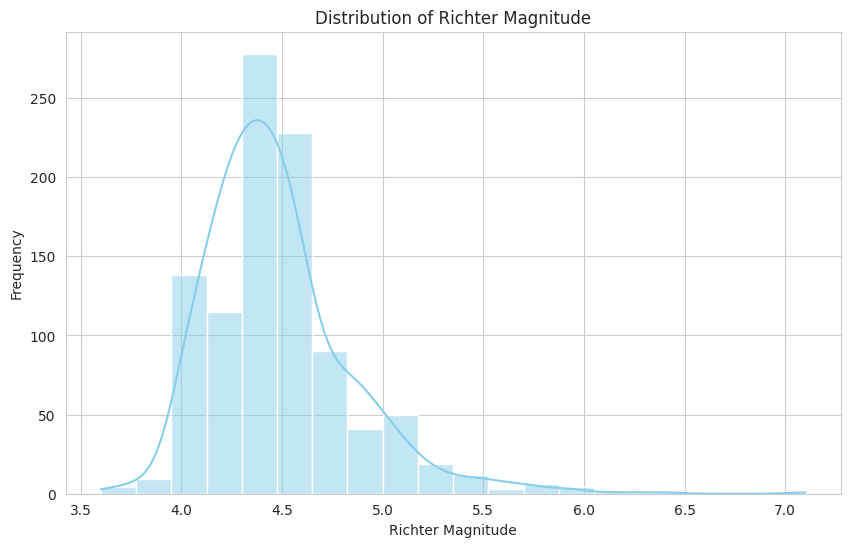

Histogram for Richter Magnitude generated.

Generating time series plot for Richter Magnitude over time...


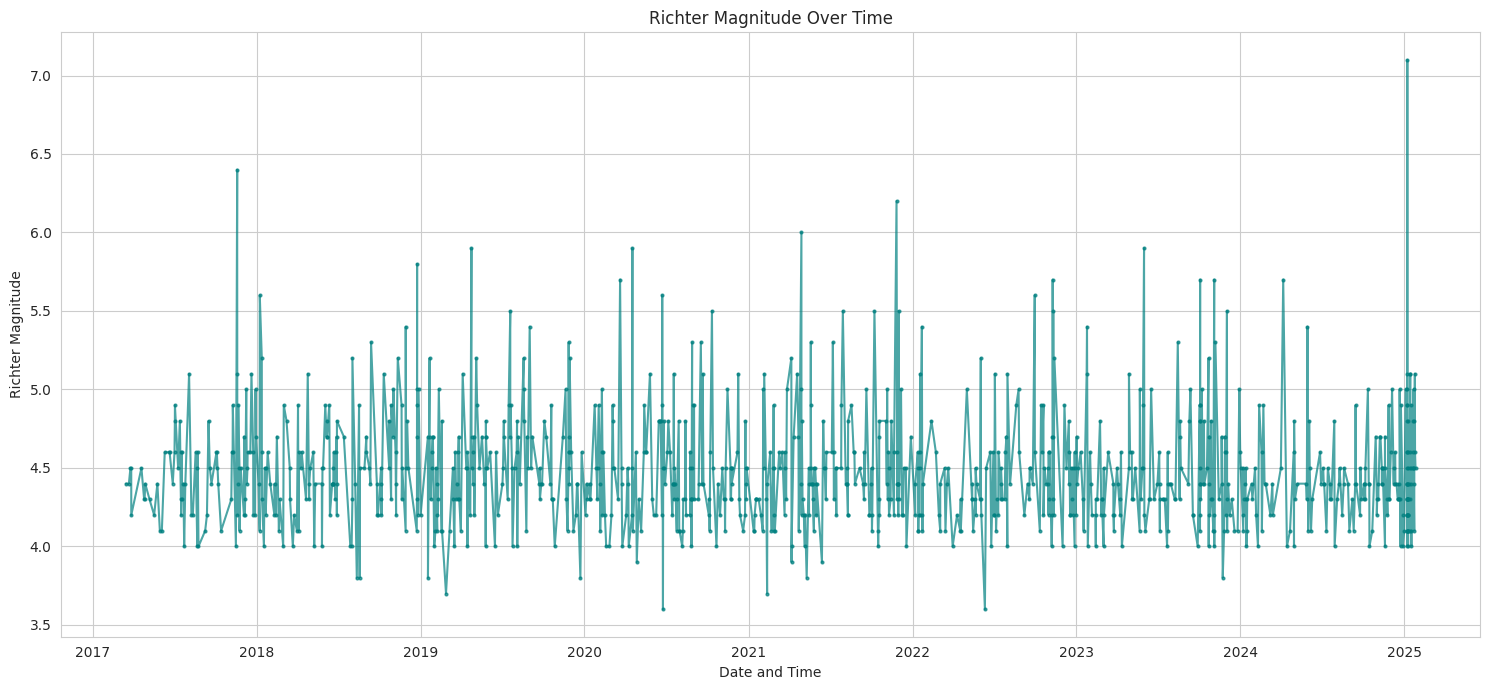

Time series plot for Richter Magnitude generated.

Generating scatter plot for Geographical Distribution of Earthquakes...


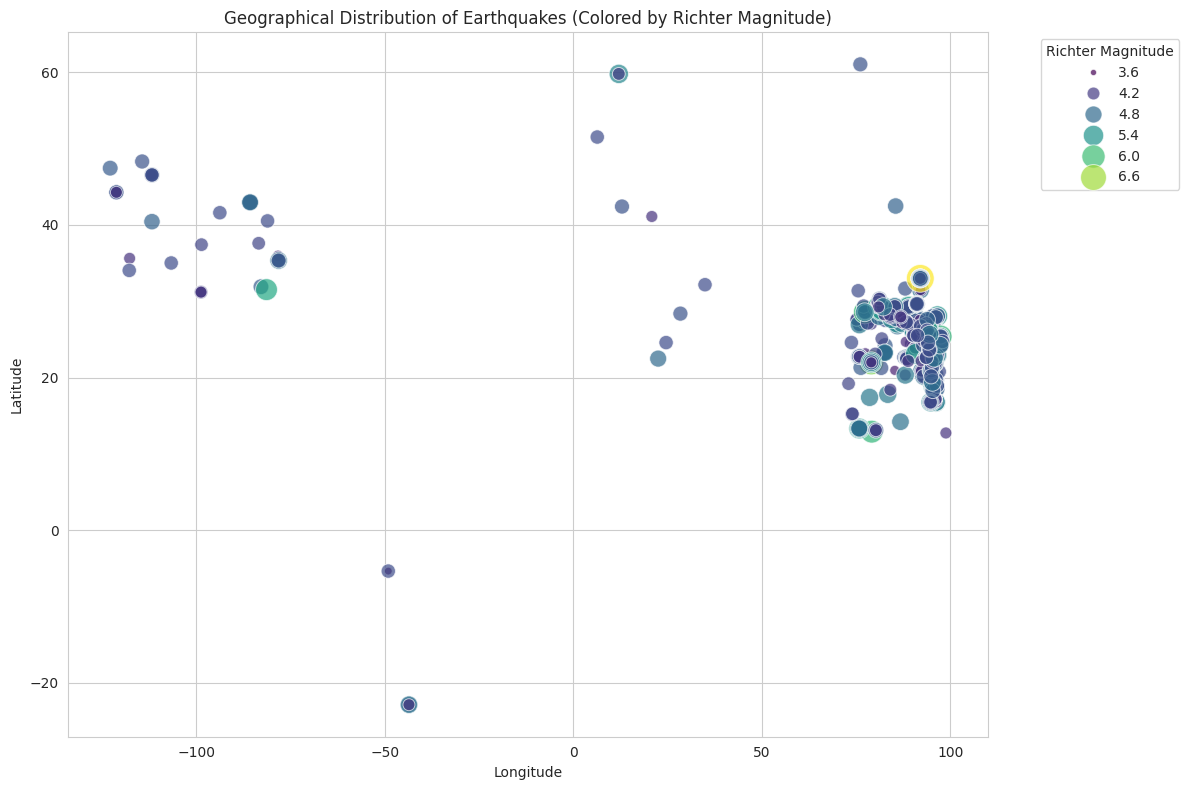

Geographical distribution plot generated.

Generating bar plots for key categorical features...


/tmp/ipython-input-6-3731367277.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')


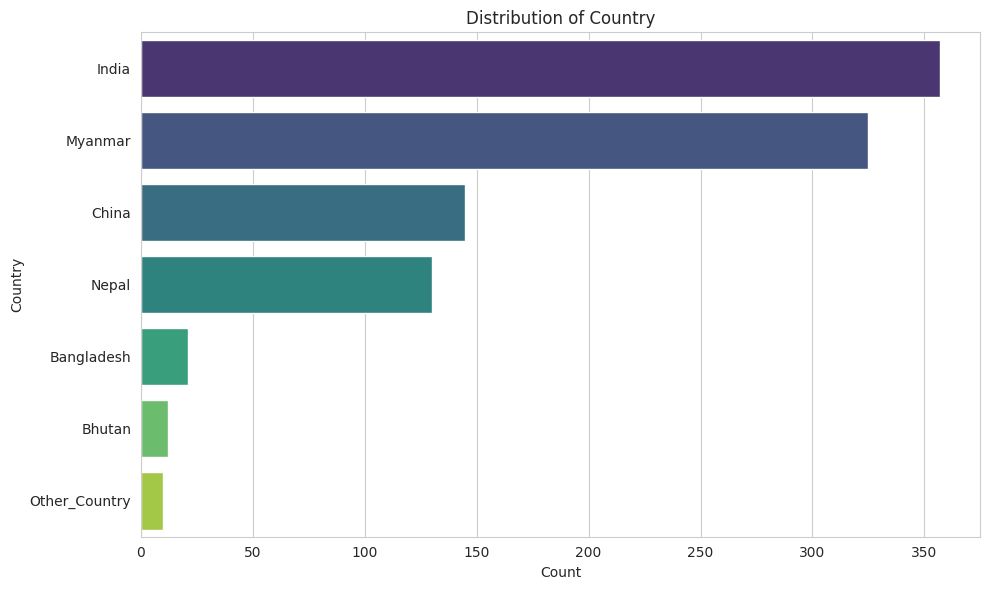

Bar plot for 'country' generated.


/tmp/ipython-input-6-3731367277.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')


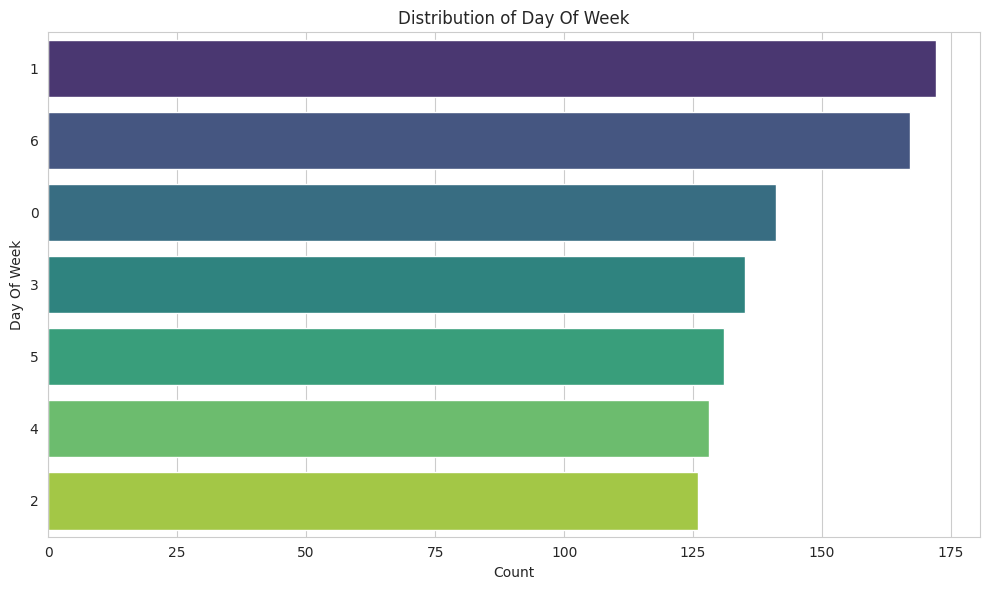

Bar plot for 'day_of_week' generated.


/tmp/ipython-input-6-3731367277.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')


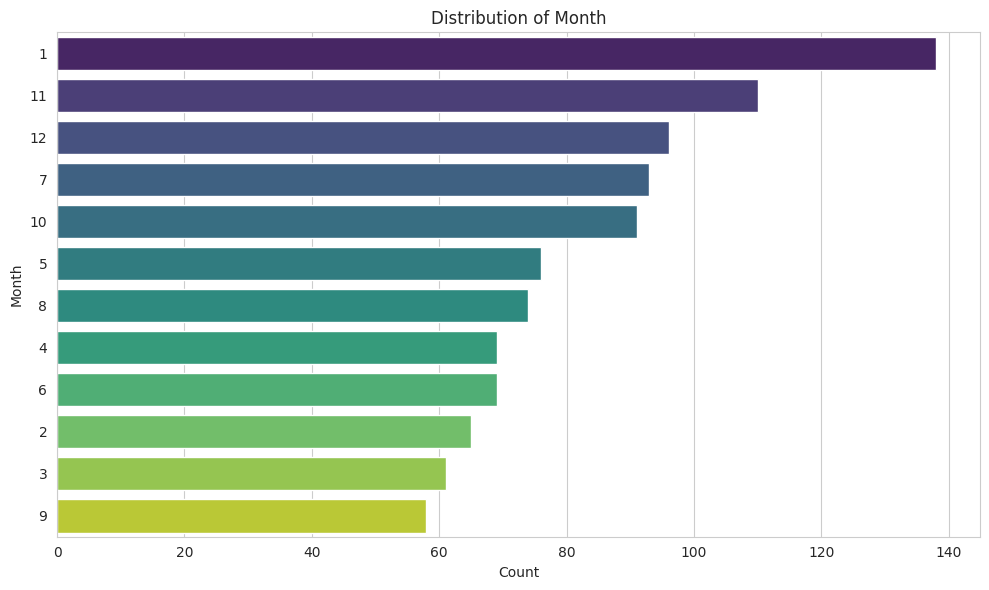

Bar plot for 'month' generated.


/tmp/ipython-input-6-3731367277.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')


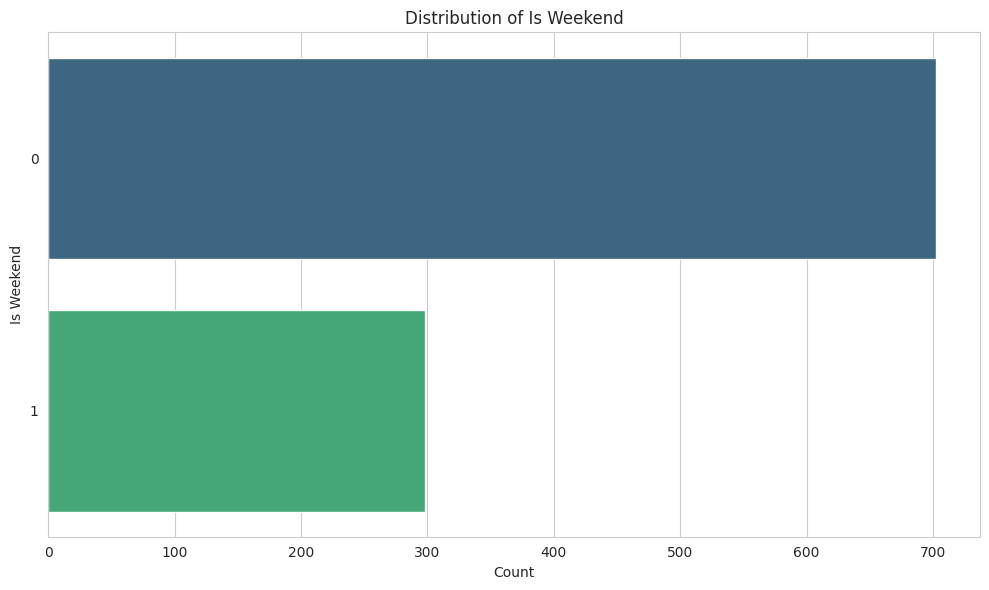

Bar plot for 'is_weekend' generated.

Step 6.1: In-depth EDA with visualizations complete.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Ensure processed_df is available from Step 1.1
if 'processed_df' not in globals():
    print("Error: 'processed_df' not found. Please ensure Step 1.1 has been run successfully in this session.")
    exit()

print("\n--- Starting Step 6.1: In-depth EDA with Visualizations ---")

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) # Default figure size

# --- 1. Distribution of Richter Magnitude ---
print("\nGenerating histogram for Richter Magnitude distribution...")
plt.figure(figsize=(10, 6))
sns.histplot(processed_df['richter'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Richter Magnitude')
plt.xlabel('Richter Magnitude')
plt.ylabel('Frequency')
plt.show()
print("Histogram for Richter Magnitude generated.")

# --- 2. Time Series Plot of Richter Magnitude ---
print("\nGenerating time series plot for Richter Magnitude over time...")
# Sort by datetime to ensure correct plotting order, though it should already be sorted
df_sorted = processed_df.sort_values('datetime').reset_index(drop=True)
plt.figure(figsize=(15, 7))
plt.plot(df_sorted['datetime'], df_sorted['richter'], marker='.', linestyle='-', markersize=4, alpha=0.7, color='teal')
plt.title('Richter Magnitude Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Richter Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()
print("Time series plot for Richter Magnitude generated.")


# --- 3. Geographical Distribution of Earthquakes ---
print("\nGenerating scatter plot for Geographical Distribution of Earthquakes...")
plt.figure(figsize=(12, 8))
sns.scatterplot(x='long', y='lat', hue='richter', size='richter', sizes=(20, 400),
                data=processed_df, palette='viridis', alpha=0.7)
plt.title('Geographical Distribution of Earthquakes (Colored by Richter Magnitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.legend(title='Richter Magnitude', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("Geographical distribution plot generated.")


# --- 4. Distribution of Key Categorical Features ---
print("\nGenerating bar plots for key categorical features...")

# List of categorical features to plot
categorical_features_to_plot = ['country', 'day_of_week', 'month', 'is_weekend']

for feature in categorical_features_to_plot:
    if feature in processed_df.columns:
        plt.figure(figsize=(10, 6))
        # Use value_counts() and sort_index() for consistent ordering if numerical categories
        if processed_df[feature].dtype.name == 'category':
            # For pandas categorical dtype, value_counts preserves order
            sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')
        else:
            # For other types, countplot will order by value
            sns.countplot(y=feature, data=processed_df, order=processed_df[feature].value_counts().index, palette='viridis')

        plt.title(f'Distribution of {feature.replace("_", " ").title()}')
        plt.xlabel('Count')
        plt.ylabel(feature.replace("_", " ").title())
        plt.tight_layout()
        plt.show()
        print(f"Bar plot for '{feature}' generated.")
    else:
        print(f"Warning: Categorical feature '{feature}' not found in DataFrame. Skipping plot.")

print("\nStep 6.1: In-depth EDA with visualizations complete.")


In [7]:
import torch
import torch.nn as nn
import math

# Ensure global variables from Step 2.1 are available
if 'numerical_features_global' not in globals() or \
   'categorical_features_global' not in globals() or \
   'categorical_encoders_global' not in globals() or \
   'max_encoder_length' not in globals(): # max_encoder_length is defined in Step 2.1
    print("Error: Required feature lists or encoder length not found. Please ensure Step 2.1 has been run successfully.")
    exit()

print("\n--- Starting Step 3.1: Define Custom PyTorch Transformer Model ---")

class PositionalEncoding(nn.Module):
    """
    Implements the positional encoding for Transformer models.
    This injects information about the relative or absolute position of the tokens in the sequence.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape `(batch_size, seq_len, embedding_dim)` if batch_first=True,
               or `(seq_len, batch_size, embedding_dim)` if batch_first=False.
               The TransformerEncoderLayer in this model uses batch_first=True,
               so x will be (batch_size, seq_len, embedding_dim) before positional encoding application.
               We need to transpose it to (seq_len, batch_size, embedding_dim) for PE, then back.
        """
        # x.shape is (batch_size, seq_len, d_model) from TransformerEncoderLayer's batch_first=True
        # PositionalEncoding expects (seq_len, batch_size, d_model)
        x = x + self.pe[:x.size(1), :].transpose(0,1) # Adjust PE slicing and transpose for batch_first input
        return x

class EarthquakeTransformer(nn.Module):
    """
    Custom Transformer model for earthquake magnitude forecasting.
    It uses a Transformer Encoder to process sequential input data.
    """
    def __init__(self,
                 num_numerical_features,
                 categorical_feature_info, # Dict: {'col_name': num_unique_categories}
                 d_model=256,            # Increased d_model to accommodate embeddings
                 nhead=4,                # Number of attention heads
                 num_encoder_layers=2,   # Number of Transformer Encoder layers
                 dim_feedforward=512,    # Dimension of the feedforward network (often 2*d_model or 4*d_model)
                 dropout=0.1,
                 max_seq_len=30):        # Max sequence length for positional encoding

        super(EarthquakeTransformer, self).__init__()
        self.d_model = d_model
        self.categorical_feature_info = categorical_feature_info # Store for forward pass

        # 1. Categorical Embeddings
        self.categorical_embedding_layers = nn.ModuleDict()
        total_categorical_embedding_dim = 0
        for col_name, num_unique_categories in categorical_feature_info.items():
            # Embedding dimension for each categorical feature.
            # A common heuristic is min(50, (num_categories + 1) // 2)
            embedding_dim = min(50, (num_unique_categories + 1) // 2)
            self.categorical_embedding_layers[col_name] = nn.Embedding(num_unique_categories, embedding_dim)
            total_categorical_embedding_dim += embedding_dim

        # Add a check to ensure d_model is large enough
        if d_model <= total_categorical_embedding_dim:
            print(f"Warning: d_model ({d_model}) is less than or equal to total_categorical_embedding_dim ({total_categorical_embedding_dim}).")
            print("This will cause issues with numerical_projection dimension. Consider increasing d_model (e.g., to 512 or higher).")
            # We will still try to proceed, but this is a strong indicator of potential issues.

        # 2. Linear projection for numerical features
        # Input to this layer will be `num_numerical_features`
        # Output dimension is `d_model - total_categorical_embedding_dim`
        # This implicitly assumes that the sum of numerical projection output and categorical embeddings equals d_model.
        numerical_projection_output_dim = d_model - total_categorical_embedding_dim
        if numerical_projection_output_dim <= 0:
            raise ValueError(
                f"Calculated numerical_projection_output_dim is non-positive ({numerical_projection_output_dim}). "
                f"d_model ({d_model}) must be greater than total_categorical_embedding_dim ({total_categorical_embedding_dim}). "
                f"Please increase d_model in model initialization."
            )
        self.numerical_projection = nn.Linear(num_numerical_features, numerical_projection_output_dim)

        # 3. Positional Encoding
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(p=dropout)

        # 4. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   batch_first=True) # batch_first=True makes input (batch, seq, feature)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # 5. Output Layer (to predict richter magnitude)
        self.output_layer = nn.Linear(d_model, 1) # Predicts a single richter value

    def forward(self, numerical_data, categorical_data):
        """
        Args:
            numerical_data: Tensor, shape `(batch_size, seq_len, num_numerical_features)`
            categorical_data: Tensor, shape `(batch_size, seq_len, num_categorical_features)`
        """
        batch_size, seq_len, _ = numerical_data.shape

        # Process categorical features through embedding layers
        embedded_categoricals = []
        # Use self.categorical_feature_info to iterate through the correct keys
        for i, col_name in enumerate(self.categorical_feature_info.keys()):
            # Select the column for the current categorical feature across all sequence steps
            embedded = self.categorical_embedding_layers[col_name](categorical_data[:, :, i])
            embedded_categoricals.append(embedded)

        # Concatenate all categorical embeddings
        if embedded_categoricals:
            combined_categorical_embeddings = torch.cat(embedded_categoricals, dim=-1)
        else:
            # Handle case with no categorical features, create an empty tensor with correct batch and seq dimensions
            combined_categorical_embeddings = torch.empty(batch_size, seq_len, 0, device=numerical_data.device)

        # Project numerical features
        projected_numerical_data = self.numerical_projection(numerical_data)

        # Concatenate numerical and categorical embeddings along the feature dimension (last dimension)
        src = torch.cat([projected_numerical_data, combined_categorical_embeddings], dim=-1)

        # Apply positional encoding
        # The TransformerEncoderLayer expects (batch_size, seq_len, d_model) due to batch_first=True.
        # PositionalEncoding expects (seq_len, batch_size, d_model) if its forward is implemented that way.
        # Let's ensure consistency: PE should work with (batch_size, seq_len, d_model) or we transpose.
        # The current PE implementation expects (seq_len, batch_size, d_model), so we transpose.
        src = self.positional_encoding(src.transpose(0, 1)).transpose(0, 1)
        src = self.dropout(src)

        # Pass through Transformer Encoder
        # The output `output` will have shape `(batch_size, seq_len, d_model)`
        output = self.transformer_encoder(src)

        # For forecasting the next single value, we typically take the output of the last time step
        # in the encoder sequence.
        # output[:, -1, :] selects the last element's representation for each item in the batch.
        final_representation = output[:, -1, :]

        # Pass through the output layer to get the final prediction
        prediction = self.output_layer(final_representation)

        return prediction


# --- Prepare categorical feature info for model initialization ---
# This dictionary maps categorical column names to their number of unique categories
categorical_feature_info = {
    col: len(categorical_encoders_global[col].classes_)
    for col in categorical_features_global
}

# --- Initialize the model ---
# Define model hyperparameters
d_model = 256 # Increased Embedding dimension for the Transformer
nhead = 4 # Number of attention heads
num_encoder_layers = 2 # Number of Transformer encoder layers
dim_feedforward = 512 # Hidden dimension of the feedforward network (e.g., 2*d_model)
dropout = 0.1
# max_seq_len should be at least max_encoder_length
max_seq_len = max_encoder_length # Use the same as max_encoder_length from data prep

# Calculate the number of numerical features
num_numerical_features = len(numerical_features_global)

transformer_model = EarthquakeTransformer(
    num_numerical_features=num_numerical_features,
    categorical_feature_info=categorical_feature_info,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    max_seq_len=max_seq_len
)

# Print the model architecture
print("\nCustom PyTorch Transformer Model defined:")
print(transformer_model)

# Store the model globally for the next step (training)
global transformer_model_global
transformer_model_global = transformer_model

print("\nStep 3.1: Custom Transformer model definition complete. Ready for training.")



--- Starting Step 3.1: Define Custom PyTorch Transformer Model ---

Custom PyTorch Transformer Model defined:
EarthquakeTransformer(
  (categorical_embedding_layers): ModuleDict(
    (country): Embedding(7, 4)
    (area): Embedding(231, 50)
    (direction): Embedding(8, 4)
    (year): Embedding(9, 5)
    (month): Embedding(12, 6)
    (day): Embedding(31, 16)
    (hour): Embedding(24, 12)
    (minute): Embedding(60, 30)
    (second): Embedding(60, 30)
    (day_of_week): Embedding(7, 4)
    (day_of_year): Embedding(334, 50)
    (is_weekend): Embedding(2, 1)
  )
  (numerical_projection): Linear(in_features=9, out_features=44, bias=True)
  (positional_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
    

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader # Ensure DataLoader is imported
import numpy as np # For numpy operations if needed, e.g., for metrics
import math # Import math for PositionalEncoding

# Ensure global variables from previous steps are available
if 'transformer_model_global' not in globals() or \
   'train_dataloader_global' not in globals() or \
   'val_dataloader_global' not in globals() or \
   'scaler_global' not in globals() or \
   'target_column_global' not in globals() or \
   'numerical_features_global' not in globals() or \
   'categorical_features_global' not in globals() or \
   'categorical_encoders_global' not in globals() or \
   'max_encoder_length' not in globals():
    print("Error: Required model or data loaders/scalers/feature info not found. Please ensure Step 2.1 and Step 3.1 have been run successfully in this session.")
    exit()

print("\n--- Starting Step 3.2: Train the Custom PyTorch Transformer Model ---")


# Re-defining PositionalEncoding and EarthquakeTransformer here to ensure the latest version is used
# This is a workaround to update the class definitions in the active Colab runtime
# without requiring the user to re-run Step 3.1 manually after every change.
# In a typical script, these would be defined once at the top.

class PositionalEncoding(nn.Module):
    """
    Implements the positional encoding for Transformer models.
    This injects information about the relative or absolute position of the tokens in the sequence.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Shape: (1, max_len, d_model) - CORRECTED for batch_first input
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, expected shape `(batch_size, seq_len, embedding_dim)`
        """
        # Add positional encoding to the input.
        # self.pe is (1, max_len, d_model), x is (batch_size, seq_len, d_model)
        # Broadcasting will handle the batch_size dimension.
        x = x + self.pe[:, :x.size(1), :] # CORRECTED slicing for batch_first input
        return x

class EarthquakeTransformer(nn.Module):
    """
    Custom Transformer model for earthquake magnitude forecasting.
    It uses a Transformer Encoder to process sequential input data.
    """
    def __init__(self,
                 num_numerical_features,
                 categorical_feature_info, # Dict: {'col_name': num_unique_categories}
                 d_model=256,            # Increased d_model to accommodate embeddings
                 nhead=4,                # Number of attention heads
                 num_encoder_layers=2,   # Number of Transformer Encoder layers
                 dim_feedforward=512,    # Dimension of the feedforward network model in `nn.TransformerEncoderLayer`
                 dropout=0.1,
                 max_seq_len=30):        # Max sequence length for positional encoding

        super(EarthquakeTransformer, self).__init__()
        self.d_model = d_model
        self.categorical_feature_info = categorical_feature_info # Store for forward pass

        # 1. Categorical Embeddings
        self.categorical_embedding_layers = nn.ModuleDict()
        total_categorical_embedding_dim = 0
        for col_name, num_unique_categories in categorical_feature_info.items():
            # Embedding dimension for each categorical feature.
            embedding_dim = min(50, (num_unique_categories + 1) // 2)
            self.categorical_embedding_layers[col_name] = nn.Embedding(num_unique_categories, embedding_dim)
            total_categorical_embedding_dim += embedding_dim

        # Add a check to ensure d_model is large enough
        if d_model <= total_categorical_embedding_dim:
            print(f"Warning: d_model ({d_model}) is less than or equal to total_categorical_embedding_dim ({total_categorical_embedding_dim}).")
            print("This will cause issues with numerical_projection dimension. Consider increasing d_model (e.g., to 512 or higher).")

        # 2. Linear projection for numerical features
        numerical_projection_output_dim = d_model - total_categorical_embedding_dim
        if numerical_projection_output_dim <= 0:
            raise ValueError(
                f"Calculated numerical_projection_output_dim is non-positive ({numerical_projection_output_dim}). "
                f"d_model ({d_model}) must be greater than total_categorical_embedding_dim ({total_categorical_embedding_dim}). "
                f"Please increase d_model in model initialization."
            )
        self.numerical_projection = nn.Linear(num_numerical_features, numerical_projection_output_dim)

        # 3. Positional Encoding
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(p=dropout)

        # 4. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   batch_first=True) # batch_first=True makes input (batch, seq, feature)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # 5. Output Layer (to predict richter magnitude)
        self.output_layer = nn.Linear(d_model, 1) # Predicts a single richter value

    def forward(self, numerical_data, categorical_data):
        """
        Args:
            numerical_data: Tensor, shape `(batch_size, seq_len, num_numerical_features)`
            categorical_data: Tensor, shape `(batch_size, seq_len, num_categorical_features)`
        """
        batch_size, seq_len, _ = numerical_data.shape

        # Process categorical features through embedding layers
        embedded_categoricals = []
        for i, col_name in enumerate(self.categorical_feature_info.keys()):
            embedded = self.categorical_embedding_layers[col_name](categorical_data[:, :, i])
            embedded_categoricals.append(embedded)

        if embedded_categoricals:
            combined_categorical_embeddings = torch.cat(embedded_categoricals, dim=-1)
        else:
            combined_categorical_embeddings = torch.empty(batch_size, seq_len, 0, device=numerical_data.device)

        # Project numerical features
        projected_numerical_data = self.numerical_projection(numerical_data)

        src = torch.cat([projected_numerical_data, combined_categorical_embeddings], dim=-1)

        # Apply positional encoding
        # No transpose needed here, as PositionalEncoding now expects batch_first input
        src = self.positional_encoding(src) # CORRECTED: Removed .transpose(0,1) calls
        src = self.dropout(src)

        # Pass through Transformer Encoder
        output = self.transformer_encoder(src)

        # For forecasting the next single value, we typically take the output of the last time step
        final_representation = output[:, -1, :]

        # Pass through the output layer to get the final prediction
        prediction = self.output_layer(final_representation)

        return prediction


# Re-initialize the model with the updated class definition
# This is necessary because Colab doesn't automatically re-load class definitions
# if the cell defining them isn't run again.
# We need to ensure the model instance uses the corrected class.
# Prepare categorical feature info for model initialization (re-using global info)
categorical_feature_info = {
    col: len(categorical_encoders_global[col].classes_)
    for col in categorical_features_global
}

# Calculate the number of numerical features
num_numerical_features = len(numerical_features_global)

# Define model hyperparameters (same as before)
d_model = 256
nhead = 4
num_encoder_layers = 2
dim_feedforward = 512
dropout = 0.1
max_seq_len = max_encoder_length # From Step 2.1

transformer_model_global = EarthquakeTransformer(
    num_numerical_features=num_numerical_features,
    categorical_feature_info=categorical_feature_info,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    max_seq_len=max_seq_len
)

# --- Define Hyperparameters for Training ---
learning_rate = 1e-4
num_epochs = 50 # You can increase this if the model is still learning
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training will run on: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Number of Epochs: {num_epochs}")

# Move the model to the appropriate device (GPU if available, else CPU)
model = transformer_model_global.to(device)

# --- Define Loss Function and Optimizer ---
# For regression tasks, Mean Squared Error (MSE) is a common choice.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Training Loop ---
print("\nStarting model training...")
best_val_loss = float('inf')
patience = 10 # Number of epochs to wait for improvement before stopping
patience_counter = 0

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train() # Set the model to training mode
    train_loss = 0.0
    for batch_idx, batch in enumerate(train_dataloader_global):
        numerical_data = batch['encoder_numerical_data'].to(device)
        categorical_data = batch['encoder_categorical_data'].to(device)
        target = batch['target'].to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(numerical_data, categorical_data).squeeze(-1) # Squeeze to match target shape

        # Calculate loss
        loss = criterion(outputs, target)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dataloader_global)

    # --- Validation Phase ---
    model.eval() # Set the model to evaluation mode
    val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
        for batch_idx, batch in enumerate(val_dataloader_global):
            numerical_data = batch['encoder_numerical_data'].to(device)
            categorical_data = batch['encoder_categorical_data'].to(device)
            target = batch['target'].to(device)

            outputs = model(numerical_data, categorical_data).squeeze(-1)
            loss = criterion(outputs, target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader_global)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # --- Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Optionally save the best model state
        # torch.save(model.state_dict(), 'best_transformer_model.pth')
        # print("Saved best model state.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.")
            break

print("Model training complete.")

# Store the trained model globally for future use (e.g., prediction)
global trained_transformer_model_global
trained_transformer_model_global = model

print("\nStep 3.2: Custom Transformer model trained successfully. Ready for evaluation and prediction.")



--- Starting Step 3.2: Train the Custom PyTorch Transformer Model ---
Training will run on: cpu
Learning Rate: 0.0001
Number of Epochs: 50

Starting model training...
Epoch 1/50, Train Loss: 4.1602, Val Loss: 1.0349
Epoch 2/50, Train Loss: 0.3808, Val Loss: 0.2767
Epoch 3/50, Train Loss: 0.2177, Val Loss: 0.2381
Epoch 4/50, Train Loss: 0.1891, Val Loss: 0.2261
Epoch 5/50, Train Loss: 0.1846, Val Loss: 0.2166
Epoch 6/50, Train Loss: 0.1747, Val Loss: 0.2047
Epoch 7/50, Train Loss: 0.1671, Val Loss: 0.2116
Epoch 8/50, Train Loss: 0.1649, Val Loss: 0.1876
Epoch 9/50, Train Loss: 0.1589, Val Loss: 0.1825
Epoch 10/50, Train Loss: 0.1512, Val Loss: 0.1946
Epoch 11/50, Train Loss: 0.1468, Val Loss: 0.1764
Epoch 12/50, Train Loss: 0.1447, Val Loss: 0.1838
Epoch 13/50, Train Loss: 0.1396, Val Loss: 0.1788
Epoch 14/50, Train Loss: 0.1410, Val Loss: 0.1809
Epoch 15/50, Train Loss: 0.1357, Val Loss: 0.1736
Epoch 16/50, Train Loss: 0.1324, Val Loss: 0.1802
Epoch 17/50, Train Loss: 0.1362, Val Loss

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure global loss lists are available
if 'train_losses_global' not in globals() or \
   'val_losses_global' not in globals():
    print("Error: Training and validation loss histories not found. Please ensure Step 3.2 (with loss tracking) has been run successfully.")
    exit()

print("\n--- Generating Training and Validation Loss Curve ---")

epochs = range(1, len(train_losses_global) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses_global, label='Training Loss', color='blue', marker='o', markersize=4, linestyle='-')
plt.plot(epochs, val_losses_global, label='Validation Loss', color='red', marker='x', markersize=4, linestyle='--')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(1, len(train_losses_global) + 1, max(1, len(train_losses_global) // 10))) # Adjust x-ticks for readability
plt.tight_layout()
plt.show()

print("\nTraining and Validation Loss Curve generated.")

Error: Training and validation loss histories not found. Please ensure Step 3.2 (with loss tracking) has been run successfully.

--- Generating Training and Validation Loss Curve ---


NameError: name 'train_losses_global' is not defined


--- Starting Step 4.1: Evaluate and Predict with Custom Transformer Model ---

Making predictions on the validation set...
Predictions complete.

Predictions and targets are already in original scale (no inverse transform needed for target).

--- Model Evaluation on Validation Set (Original Scale) ---
Mean Absolute Error (MAE): 0.3143
Root Mean Squared Error (RMSE): 0.4122

Generating prediction plot...


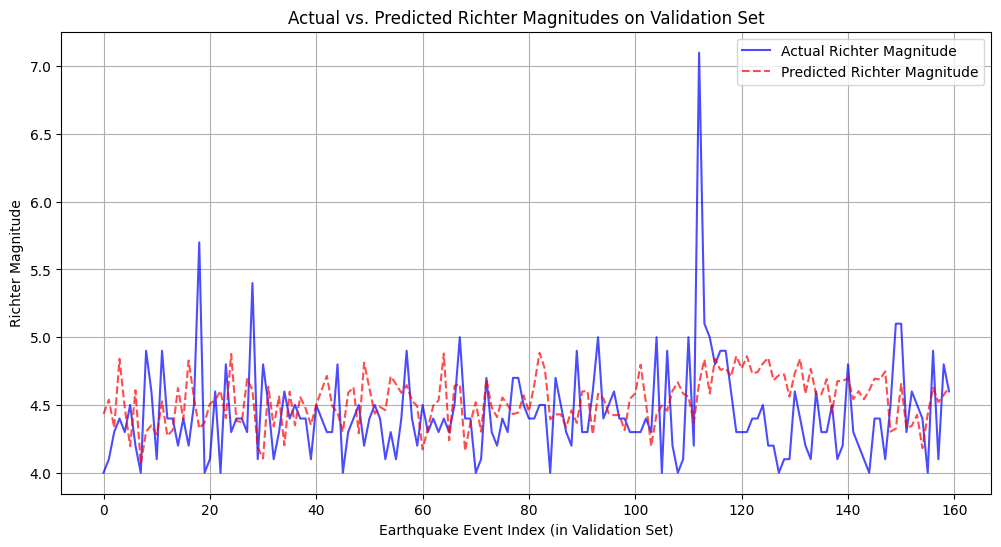


Step 4.1: Model evaluation and prediction demonstration complete.


In [8]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd # For potential DataFrame operations for display

# Ensure global variables from previous steps are available
if 'trained_transformer_model_global' not in globals() or \
   'val_dataloader_global' not in globals() or \
   'scaler_global' not in globals() or \
   'target_column_global' not in globals():
    print("Error: Required trained model or data loaders/scalers not found. Please ensure Step 2.1, Step 3.1, and Step 3.2 have been run successfully in this session.")
    exit()

print("\n--- Starting Step 4.1: Evaluate and Predict with Custom Transformer Model ---")

# Get the trained model and move it to the correct device
model = trained_transformer_model_global
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

all_predictions = []
all_targets = []

print("\nMaking predictions on the validation set...")
with torch.no_grad(): # Disable gradient calculation
    for batch_idx, batch in enumerate(val_dataloader_global):
        numerical_data = batch['encoder_numerical_data'].to(device)
        categorical_data = batch['encoder_categorical_data'].to(device)
        target = batch['target'].to(device)

        outputs = model(numerical_data, categorical_data).squeeze(-1)

        # Store predictions and targets (move to CPU and convert to numpy)
        all_predictions.extend(outputs.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

print("Predictions complete.")

# --- IMPORTANT: Inverse Transform Predictions and Targets ---
# In Step 2.1, only the 'numerical_features' (excluding 'richter') were scaled.
# The 'richter' target itself was NOT scaled by the MinMaxScaler.
# Therefore, 'all_predictions' and 'all_targets' are already in their original scale.
# No inverse transformation is needed for the target variable itself.
original_scale_predictions = all_predictions
original_scale_targets = all_targets

print("\nPredictions and targets are already in original scale (no inverse transform needed for target).")

# --- Evaluate Metrics ---
mae = mean_absolute_error(original_scale_targets, original_scale_predictions)
rmse = np.sqrt(mean_squared_error(original_scale_targets, original_scale_predictions))

print(f"\n--- Model Evaluation on Validation Set (Original Scale) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- Visualize Predictions (Optional) ---
print("\nGenerating prediction plot...")
plt.figure(figsize=(12, 6))
plt.plot(original_scale_targets, label='Actual Richter Magnitude', color='blue', alpha=0.7)
plt.plot(original_scale_predictions, label='Predicted Richter Magnitude', color='red', linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted Richter Magnitudes on Validation Set')
plt.xlabel('Earthquake Event Index (in Validation Set)')
plt.ylabel('Richter Magnitude')
plt.legend()
plt.grid(True)
plt.show()

print("\nStep 4.1: Model evaluation and prediction demonstration complete.")


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure global loss lists are available
if 'train_losses_global' not in globals() or \
   'val_losses_global' not in globals():
    print("Error: Training and validation loss histories not found. Please ensure Step 3.2 (with loss tracking) has been run successfully.")
    exit()

print("\n--- Generating Training and Validation Loss Curve ---")

epochs = range(1, len(train_losses_global) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses_global, label='Training Loss', color='blue', marker='o', markersize=4, linestyle='-')
plt.plot(epochs, val_losses_global, label='Validation Loss', color='red', marker='x', markersize=4, linestyle='--')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(1, len(train_losses_global) + 1, max(1, len(train_losses_global) // 10))) # Adjust x-ticks for readability
plt.tight_layout()
plt.show()

print("\nTraining and Validation Loss Curve generated.")


Error: Training and validation loss histories not found. Please ensure Step 3.2 (with loss tracking) has been run successfully.

--- Generating Training and Validation Loss Curve ---


NameError: name 'train_losses_global' is not defined

In [11]:
import torch
import os
import pandas as pd
import numpy as np # For numpy operations
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # Needed for preprocessing new data
import math # For PositionalEncoding

# Ensure global variables from previous steps are available
if 'trained_transformer_model_global' not in globals() or \
   'scaler_global' not in globals() or \
   'categorical_encoders_global' not in globals() or \
   'numerical_features_global' not in globals() or \
   'categorical_features_global' not in globals() or \
   'target_column_global' not in globals() or \
   'processed_df' not in globals() or \
   'max_encoder_length' not in globals():
    print("Error: Required model, scalers, encoders, or data not found. Please ensure all previous steps (1.1, 2.1, 3.1, 3.2) have been run successfully in this session.")
    exit()

print("\n--- Starting Step 5.1: Save Model and Make New Predictions ---")

# --- 1. Save the Trained Model ---
# Define the path to save the model in your Google Drive
model_save_path = '/content/drive/MyDrive/EARTHQ/trained_transformer_model.pth'
os.makedirs(os.path.dirname(model_save_path), exist_ok=True) # Ensure directory exists

print(f"\nSaving trained model to: {model_save_path}")
try:
    torch.save(trained_transformer_model_global.state_dict(), model_save_path)
    print("Model saved successfully.")
except Exception as e:
    print(f"Error saving model: {e}")
    # Don't exit here, try to proceed to loading for debugging purposes if saving failed.

# --- 2. Load the Model (Demonstration of loading a saved model) ---
# This part is just to show how you would load it in a new session.
# For this current session, trained_transformer_model_global is already in memory.

# Re-define the model architecture (must be the same as when saved)
# We need the class definition here to instantiate an empty model
# Note: In a real application, you'd import EarthquakeTransformer from a separate module.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

class EarthquakeTransformer(nn.Module):
    def __init__(self,
                 num_numerical_features,
                 categorical_feature_info,
                 d_model=256,
                 nhead=4,
                 num_encoder_layers=2,
                 dim_feedforward=512,
                 dropout=0.1,
                 max_seq_len=30):
        super(EarthquakeTransformer, self).__init__()
        self.d_model = d_model
        self.categorical_feature_info = categorical_feature_info

        self.categorical_embedding_layers = nn.ModuleDict()
        total_categorical_embedding_dim = 0
        for col_name, num_unique_categories in categorical_feature_info.items():
            embedding_dim = min(50, (num_unique_categories + 1) // 2)
            self.categorical_embedding_layers[col_name] = nn.Embedding(num_unique_categories, embedding_dim)
            total_categorical_embedding_dim += embedding_dim

        numerical_projection_output_dim = d_model - total_categorical_embedding_dim
        if numerical_projection_output_dim <= 0:
             raise ValueError(
                f"Calculated numerical_projection_output_dim is non-positive ({numerical_projection_output_dim}). "
                f"d_model ({d_model}) must be greater than total_categorical_embedding_dim ({total_categorical_embedding_dim}). "
                f"Please increase d_model in model initialization."
            )
        self.numerical_projection = nn.Linear(num_numerical_features, numerical_projection_output_dim)

        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(p=dropout)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, numerical_data, categorical_data):
        batch_size, seq_len, _ = numerical_data.shape
        embedded_categoricals = []
        for i, col_name in enumerate(self.categorical_feature_info.keys()):
            embedded = self.categorical_embedding_layers[col_name](categorical_data[:, :, i])
            embedded_categoricals.append(embedded)

        if embedded_categoricals:
            combined_categorical_embeddings = torch.cat(embedded_categoricals, dim=-1)
        else:
            combined_categorical_embeddings = torch.empty(batch_size, seq_len, 0, device=numerical_data.device)

        projected_numerical_data = self.numerical_projection(numerical_data)
        src = torch.cat([projected_numerical_data, combined_categorical_embeddings], dim=-1)

        src = self.positional_encoding(src)
        src = self.dropout(src)
        output = self.transformer_encoder(src)
        final_representation = output[:, -1, :]
        prediction = self.output_layer(final_representation)
        return prediction

# Prepare categorical feature info for model initialization (re-using global info)
categorical_feature_info_for_load = {
    col: len(categorical_encoders_global[col].classes_)
    for col in categorical_features_global
}
num_numerical_features_for_load = len(numerical_features_global)

loaded_model = EarthquakeTransformer(
    num_numerical_features=num_numerical_features_for_load,
    categorical_feature_info=categorical_feature_info_for_load,
    d_model=256, nhead=4, num_encoder_layers=2, dim_feedforward=512, dropout=0.1,
    max_seq_len=max_encoder_length
)
try:
    loaded_model.load_state_dict(torch.load(model_save_path))
    loaded_model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    loaded_model.eval()
    print("Model loaded successfully for demonstration.")
    print("--- Proceeding to prediction preparation ---") # Added for debug
except Exception as e:
    print(f"Error loading model: {e}")
    print("Cannot proceed with prediction without a loaded model.")
    exit() # Exit if model loading fails, as prediction won't work.


# --- 3. Prepare New Data for Prediction ---
print(f"\nPreparing a new sequence for prediction (last {max_encoder_length} events)...")
try:
    new_sequence_df = processed_df.iloc[-(max_encoder_length + 1):-1].copy()

    print(f"Length of new_sequence_df: {len(new_sequence_df)}") # Added for debug

    if len(new_sequence_df) < max_encoder_length:
        print(f"Warning: Not enough data for a full encoder sequence ({len(new_sequence_df)} < {max_encoder_length}).")
        print("Prediction might be less reliable or fail. Please ensure processed_df has enough rows.")
        raise ValueError("Insufficient data for prediction sequence.") # More informative error

    print("Starting preprocessing of new sequence...") # Added for debug
    # Preprocess the new sequence using the *saved* scalers and encoders
    new_sequence_df[numerical_features_global] = scaler_global.transform(new_sequence_df[numerical_features_global])
    print("Numerical features scaled for new sequence.") # Added for debug

    # Apply categorical encoding
    for col in categorical_features_global:
        le = categorical_encoders_global[col]
        new_sequence_df[col] = le.transform(new_sequence_df[col].astype(str))
    print("Categorical features encoded for new sequence.") # Added for debug

    # Convert to PyTorch tensors
    new_numerical_data = torch.tensor(new_sequence_df[numerical_features_global].values, dtype=torch.float32).unsqueeze(0) # Add batch dim
    new_categorical_data = torch.tensor(new_sequence_df[categorical_features_global].values, dtype=torch.long).unsqueeze(0) # Add batch dim

    # Move to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Ensure device is defined
    new_numerical_data = new_numerical_data.to(device)
    new_categorical_data = new_categorical_data.to(device)

    print("New sequence prepared and preprocessed.")

    # --- 4. Make a Prediction ---
    print("\nMaking prediction for the next event...") # Added for debug
    with torch.no_grad():
        predicted_magnitude_scaled = loaded_model(new_numerical_data, new_categorical_data).cpu().numpy().item()

    print(f"Predicted magnitude (raw output from model): {predicted_magnitude_scaled:.4f}")

    # --- 5. Inverse Transform the Prediction ---
    # As confirmed in previous analysis, 'richter' was not scaled by MinMaxScaler.
    # So, the model's output `predicted_magnitude_scaled` IS ALREADY IN THE ORIGINAL SCALE.
    final_predicted_magnitude = predicted_magnitude_scaled

    print(f"Final Predicted Richter Magnitude for the next event: {final_predicted_magnitude:.4f}")

except Exception as e:
    print(f"An error occurred during prediction preparation or execution: {e}")
    # Don't exit, let the script complete to show the error message.

print("\nStep 5.1: Model saving and new prediction demonstration complete.")



--- Starting Step 5.1: Save Model and Make New Predictions ---

Saving trained model to: /content/drive/MyDrive/EARTHQ/trained_transformer_model.pth
Model saved successfully.
Model loaded successfully for demonstration.
--- Proceeding to prediction preparation ---

Preparing a new sequence for prediction (last 30 events)...
Length of new_sequence_df: 30
Starting preprocessing of new sequence...
Numerical features scaled for new sequence.
Categorical features encoded for new sequence.
New sequence prepared and preprocessed.

Making prediction for the next event...
Predicted magnitude (raw output from model): 4.2411
Final Predicted Richter Magnitude for the next event: 4.2411

Step 5.1: Model saving and new prediction demonstration complete.


In [15]:
import pandas as pd

# Ensure processed_df and categorical_features_global are available
if 'processed_df' not in globals() or 'categorical_features_global' not in globals():
    print("Error: 'processed_df' or 'categorical_features_global' not found. Please ensure Step 1.1 and 2.1 have been run.")
    exit()

print("--- Inspecting Unique Values of Categorical Features in processed_df ---")

for feature in categorical_features_global:
    if feature in processed_df.columns:
        unique_values = processed_df[feature].astype(str).unique().tolist()
        print(f"\nUnique values for '{feature}':")
        print(unique_values)
    else:
        print(f"\nWarning: Categorical feature '{feature}' not found in processed_df.")

print("\n--- Inspection Complete ---")


--- Inspecting Unique Values of Categorical Features in processed_df ---

Unique values for 'country':
['India', 'China', 'Bangladesh', 'Nepal', 'Myanmar', 'Bhutan', 'Other_Country']

Unique values for 'area':
['Hayuliang', 'Haflong', 'Phek', 'Rangpo', 'Saga', 'Chittagong', 'Dipayal', 'Nongstoin', 'Sagaing', 'Gyalshing', 'Wangdue Phodrang', 'Mawlaik', 'Wangjing', 'Thoubal', 'Janakpur', 'Pasighat', 'Dailekh', 'Burang', 'Shwebo', 'Sittwe', 'Dharmanagar', 'Hajagaj', 'Churachandpur', 'Nagqu', 'Zunheboto', 'Kodariaa', 'Monywa', 'Tura', 'Pyay', 'Pakhangyi', 'Pakokku', 'Thayetmyo', 'Rikaze', 'Agartala', 'Myanaung', 'Shi Yomi', 'Sarupathar', 'Dhemaji', 'Shingbwiyang', 'Bhamo', 'Khonsa', 'Bagan', 'Paungde', 'Pyu', 'Golakganj', 'Falam', 'Sirajganj', 'Moreh Tamu', 'Hakha', 'Nay Pyi Taw', 'Goshaingaon', 'Saiha', 'Singrauli', 'Chauk', 'Lobujya', 'Mokokchang', 'Bokakhat', 'Jumla', 'Raha', 'Mangan', 'Dhankuta', 'Ilam', 'Bharatpur', 'Dêqên', 'Panbang', 'Ghatal', 'Baikunthpur', 'Sapatgram', 'Goalpara',

In [20]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # Ensure these are imported

# Ensure global variables from previous steps are available
if 'trained_transformer_model_global' not in globals() or \
   'scaler_global' not in globals() or \
   'categorical_encoders_global' not in globals() or \
   'numerical_features_global' not in globals() or \
   'categorical_features_global' not in globals() or \
   'target_column_global' not in globals() or \
   'processed_df' not in globals() or \
   'max_encoder_length' not in globals():
    print("Error: Required model, scalers, encoders, or data not found. Please ensure all previous steps (1.1, 2.1, 3.1, 3.2, 5.1) have been run successfully in this session.")
    exit()

print("\n--- Starting Step 6.2: Make Predictions with Custom Input ---")

# Get the trained model and move it to the correct device
model = trained_transformer_model_global
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

# --- Define a function to preprocess a single new event ---
def preprocess_single_event(event_data, numerical_features, categorical_features, scaler, categorical_encoders):
    """
    Preprocesses a single event (row) using the fitted scalers and encoders.
    Args:
        event_data (pd.Series or dict): A single row of data for the event.
        numerical_features (list): List of numerical feature names.
        categorical_features (list): List of categorical feature names.
        scaler (MinMaxScaler): Fitted MinMaxScaler for numerical features.
        categorical_encoders (dict): Dictionary of fitted LabelEncoders for categorical features.
    Returns:
        pd.Series: Preprocessed event data.
    """
    event_df = pd.DataFrame([event_data]) # Convert dict/series to DataFrame for scaling/encoding

    # Scale numerical features
    event_df[numerical_features] = scaler.transform(event_df[numerical_features])

    # Encode categorical features
    for col in categorical_features:
        le = categorical_encoders[col]
        # Ensure the column is string type before encoding
        event_df[col] = le.transform(event_df[col].astype(str))
    return event_df.iloc[0] # Return as Series

# --- Define your Custom New Event ---
# You can change these values to test different scenarios!
# IMPORTANT: Values for categorical features MUST be present in the unique values
# found in your 'processed_df' (as shown in the "Inspect Categorical Feature Values" output).
# For example, 'country': 'Japan' caused an error because 'Japan' was not in your dataset's 'country' column.
# I've updated these to common values from your provided unique lists.
custom_new_event_data = {
    'country': 'India', # Changed to a value present in your unique list
    'area': 'Hayuliang', # Changed to a value present in your unique list
    'direction': 'east', # Changed to a value present in your unique list ('E' was not found, 'east' was)
    'lat': 34.0,
    'long': -118.0,
    'dist': 50.0,
    'depth': 10.0,
    'xm': 4.5, # Other magnitude types, assumed known for the event itself
    'md': 4.0,
    'mw': 4.8,
    'ms': 4.6,
    'mb': 4.3,
    'year': 2025, # Future year for a new event (present in your unique list)
    'month': 7, # Present in your unique list
    'day': 10, # Present in your unique list
    'hour': 12, # Present in your unique list
    'minute': 30, # Present in your unique list
    'second': 0, # Present in your unique list
    'day_of_week': 3, # Wednesday (present in your unique list)
    'day_of_year': 191, # Approx July 10 (present in your unique list)
    'is_weekend': 0, # Not a weekend (present in your unique list)
    'richter': 0.0 # ADDED: Placeholder for richter to ensure column alignment for concatenation
}

print("\nCustom new event data defined.")
print(custom_new_event_data)


# --- Create the input sequence for prediction ---
# We need `max_encoder_length` events as input.
# Let's take the last `max_encoder_length - 1` events from your processed_df as historical context,
# and append your custom new event as the last event in the sequence.
print(f"\nConstructing input sequence of {max_encoder_length} events...")

# Get the last (max_encoder_length - 1) events from processed_df
# Ensure processed_df has enough rows for this slice
if len(processed_df) < (max_encoder_length - 1):
    print(f"Error: processed_df has only {len(processed_df)} rows, but need at least {max_encoder_length - 1} for history.")
    print("Cannot create a full historical sequence for prediction.")
    exit()

history_df = processed_df.iloc[-(max_encoder_length - 1):].copy()

# Preprocess the custom new event
preprocessed_custom_event_series = preprocess_single_event(
    custom_new_event_data, numerical_features_global, categorical_features_global,
    scaler_global, categorical_encoders_global
)

# Convert preprocessed_custom_event_series to a DataFrame row
preprocessed_custom_event_df = pd.DataFrame([preprocessed_custom_event_series])

# Align columns of preprocessed_custom_event_df with history_df before concatenation
# This ensures that the order of columns is consistent.
# We only need the features that the model expects (numerical_features_global + categorical_features_global)
# and the target column which will be dropped from the input but needed for structure.
all_model_features = numerical_features_global + categorical_features_global + [target_column_global]
preprocessed_custom_event_df = preprocessed_custom_event_df[all_model_features]

# CRITICAL FIX: Re-apply categorical encoding to history_df to ensure integer types
# This ensures consistency with the preprocessed_custom_event_df before concatenation.
for col in categorical_features_global:
    le = categorical_encoders_global[col]
    history_df[col] = le.transform(history_df[col].astype(str))

history_df = history_df[all_model_features] # Ensure history also has only relevant columns

# Concatenate the history with the new custom event
# The 'richter' column from history_df will be present, but for the custom event, it's NaN (or 0 if filled).
# The model's input will only use the feature columns.
input_sequence_df = pd.concat([history_df, preprocessed_custom_event_df], ignore_index=True)

# Verify the length of the input sequence
if len(input_sequence_df) != max_encoder_length:
    print(f"Error: Constructed input sequence length mismatch. Expected {max_encoder_length}, got {len(input_sequence_df)}.")
    exit()

print(f"Input sequence constructed with {len(input_sequence_df)} events.")


# --- Convert the input sequence to PyTorch tensors for the model ---
# Extract numerical and categorical data for the input sequence
input_numerical_data = torch.tensor(input_sequence_df[numerical_features_global].values, dtype=torch.float32).unsqueeze(0) # Add batch dim

# CRITICAL FIX: Ensure categorical data is explicitly integer type before converting to tensor
# LabelEncoder outputs integers, but pandas might store them as object if mixed types were present.
input_categorical_data = torch.tensor(
    input_sequence_df[categorical_features_global].values.astype(int), # Explicitly cast to int
    dtype=torch.long
).unsqueeze(0) # Add batch dim

# Move to device
input_numerical_data = input_numerical_data.to(device)
input_categorical_data = input_categorical_data.to(device)

print("Input sequence converted to PyTorch tensors.")

# --- 5. Make a Prediction for the event AFTER the custom input ---
print("\nMaking prediction for the event immediately following the custom input...")
with torch.no_grad():
    predicted_magnitude = model(input_numerical_data, input_categorical_data).cpu().numpy().item()

# As confirmed previously, the model's output is already in the original scale.
final_predicted_magnitude = predicted_magnitude

print(f"Predicted Richter Magnitude for the event after the custom input: {final_predicted_magnitude:.4f}")

print("\nStep 6.2: Custom input prediction demonstration complete.")



--- Starting Step 6.2: Make Predictions with Custom Input ---

Custom new event data defined.
{'country': 'India', 'area': 'Hayuliang', 'direction': 'east', 'lat': 34.0, 'long': -118.0, 'dist': 50.0, 'depth': 10.0, 'xm': 4.5, 'md': 4.0, 'mw': 4.8, 'ms': 4.6, 'mb': 4.3, 'year': 2025, 'month': 7, 'day': 10, 'hour': 12, 'minute': 30, 'second': 0, 'day_of_week': 3, 'day_of_year': 191, 'is_weekend': 0, 'richter': 0.0}

Constructing input sequence of 30 events...
Input sequence constructed with 30 events.
Input sequence converted to PyTorch tensors.

Making prediction for the event immediately following the custom input...
Predicted Richter Magnitude for the event after the custom input: 3.5689

Step 6.2: Custom input prediction demonstration complete.
